## k-최근접 이웃의 한계

In [1]:
import numpy as np
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [2]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42
)
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor(n_neighbors = 3)

knr.fit(train_input, train_target)
print(knr.predict([[50]]))

[1033.33333333]


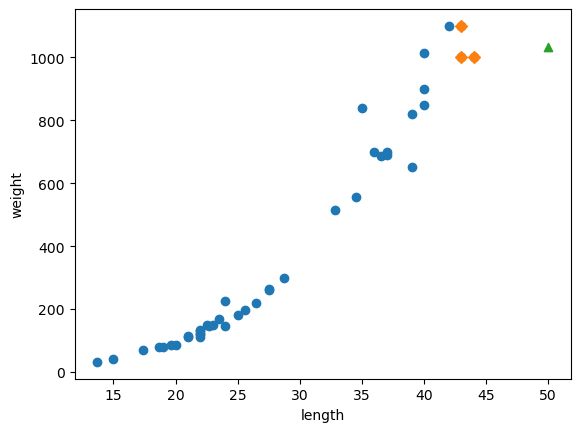

In [3]:
import matplotlib.pyplot as plt
distances, indexes = knr.kneighbors([[50]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')
plt.scatter(50, 1033, marker="^")
plt.xlabel('length')
plt.ylabel('weight')
plt.show()


In [ ]:
print(np.mean(train_target[indexes])) 
# 가장 가까운 샘플의 평균을 구하기 때문에 길이가 100이어도 1,033g으로 예측


1033.3333333333333


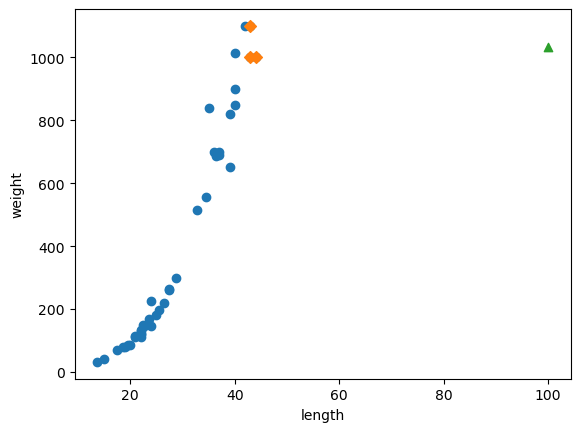

In [7]:
import matplotlib.pyplot as plt
distances, indexes = knr.kneighbors([[100]])

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')
plt.scatter(100, 1033, marker="^")
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

## 선형회귀

In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(train_input, train_target)
print(lr.predict([[50]]))

print(lr.coef_, lr.intercept_)

[1241.83860323]
[39.01714496] -709.0186449535477


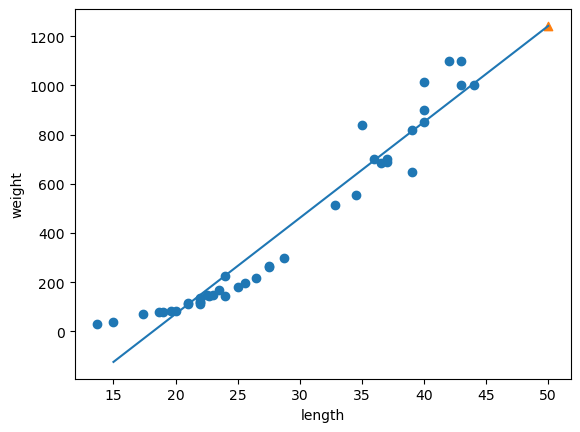

In [12]:
plt.scatter(train_input, train_target)

plt.plot([15,50], [15*lr.coef_+ lr.intercept_, 50*lr.coef_+ + lr.intercept_])
plt.scatter(50, 1241.8, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()


In [14]:
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.9398463339976041
0.8247503123313559


## 다항회귀

In [16]:
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))
print(train_poly.shape, test_poly.shape)

(42, 2) (14, 2)


In [20]:
lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.predict([[50**2, 50]]))
print(lr.coef_, lr.intercept_)

[1573.98423528]
[  1.01433211 -21.55792498] 116.0502107827827


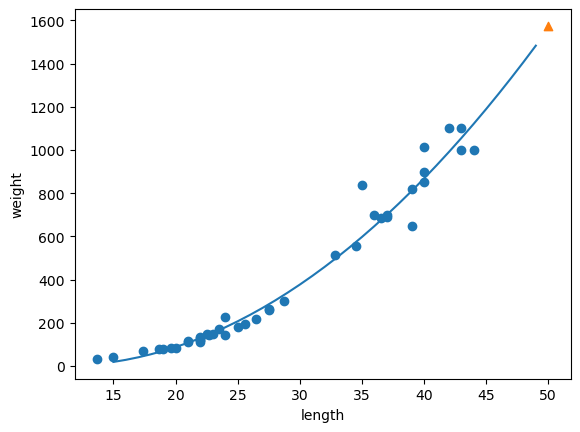

In [21]:
point = np.arange(15, 50)

plt.scatter(train_input, train_target)
plt.plot(point, 1.01*point**2 - 21.6*point + 116.05)

plt.scatter(50, 1574, marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [22]:
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9706807451768623
0.9775935108325122


In [ ]:
import pandas as pd
df = pd.read_csv('https://bit.ly/perch_csv_data')
perch_full = df.to_numpy()
print(perch_full)

In [24]:
import numpy as np
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    perch_full, perch_weight, random_state=42)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures() 
# 기본적으로 각 특성을 제곱한 항을 추가하고 특성끼리 서로 곱한 항을 추가
# 1이 추가되는 이유 : 절편을 항상 값이 1인 특성과 곱해지는 계수라고 봄
poly.fit([[2,3]]) # 새롭게 만들 특성 조합을 찾음, target data가 필요하지 않음
print(poly.transform([[2,3]])) # 실제로 데이터 변환

[[1. 2. 3. 4. 6. 9.]]


In [26]:
poly = PolynomialFeatures(include_bias=False) # 절편 특성 반환 X 
poly.fit([[2,3]])
print(poly.transform([[2,3]])) 

[[2. 3. 4. 6. 9.]]


In [28]:
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
print(train_poly.shape)

poly.get_feature_names_out() # 각각의 특성이 어떤 입력의 조합으로 만들어졌는지

(42, 9)


array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

In [29]:
test_poly = poly.transform(test_input)


In [32]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9903183436982126
0.9714559911594095


In [ ]:
poly = PolynomialFeatures(degree=5, include_bias=False) # degree : 고차항의 최대 차수 지정
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)
print(train_poly.shape)


(42, 55)


In [ ]:
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target)) # => 과대적합

0.9999999999976599
-144.4072001577299


## 규제
- 일반적으로 선형 회귀 모델에 규제를 적용할 때 계수 값의 크기가 서로 많이 다르면 공정하게 제어되지 않음
- 규제 적용 전 정규화 필요


In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler() # 클래스 객체 초기화
ss.fit(train_poly) # 꼭 훈련 세트로 변환기 사용해 테스트 세트까지 변환 왜?
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

# 선형회귀 모델에 규제를 추가한 모델 => 릿지, 라쏘
# 릿지 : 계수를 제곱한 값을 기준으로 규제 적용
# 라쏘 : 계수의 절댓값을 기준으로 규제를 적용

### 릿지 회귀

In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))
# 규제의 양을 임의로 조절 가능
# 모델 객체를 만들 때 alpha 매개변수로 규제의 강도 조절
# alpha 크면 규제강도 세짐 => 계수 값을 더 줄이고 더 과소 적합되도록

0.9896101671037343
0.9790693977615398


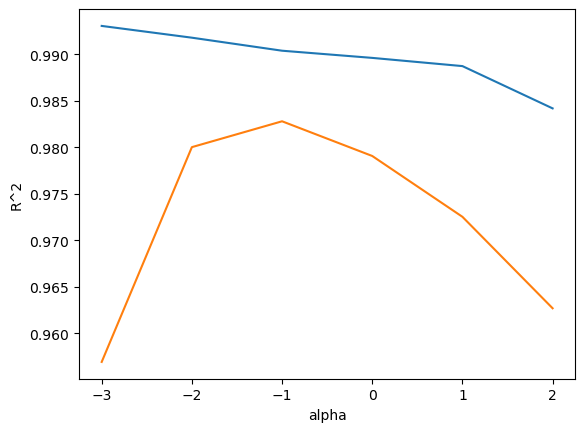

In [ ]:
# alpha값 찾기
import matplotlib.pyplot as plt
train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    # 릿지 모델 만들기
    ridge = Ridge(alpha=alpha)
    # 릿지 모델을 훈련
    ridge.fit(train_scaled, train_target)
    # 훈련 점수와 테스트 점수를 저장
    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))

plt.plot(np.log10(alpha_list), train_score)
# 왼쪽이 너무 촘촘해지는걸 방지하기 위해 지수로 표현
plt.plot(np.log10(alpha_list), test_score)
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()
# 파랑이 훈련 세트 그래프
# 주황 테스트 세트 그래프
# 여기서 alpha 값은 -1

In [45]:
ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9903815817570367
0.9827976465387009


## 라쏘 회귀

In [47]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.989789897208096
0.9800593698421884


c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.878e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\Playdata\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


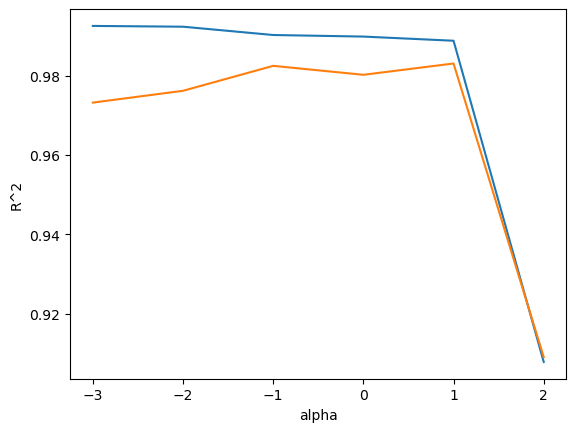

In [ ]:
# alpha값 찾기
train_score= []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    # 라쏘 모델 만들기
    lasso = Lasso(alpha=alpha, max_iter=10000)
    # 라쏘 모델 훈련
    lasso.fit(train_scaled, train_target)
    # 훈련 점수와 테스트 점수를 저장합니다.
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))

plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

# 왼쪽은 과대 적합
# 오른쪽으로 갈수록 점수 좁혀짐
# 가장 크게 떨어지는 시점부터 과소적합
# alpha = 10^1 = 10

In [49]:
lasso = Lasso(alpha=10)
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.9888067471131867
0.9824470598706695


In [50]:
print(np.sum(lasso.coef_ == 0))

40
